<a href="https://colab.research.google.com/github/fedhere/DSPS_FBianco/blob/master/labs/LocationLocationLocation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook is designed to stimulate considerations about the choice of preprocissing for categorical variables. Tree based models anable a farily untuitive insight into model performance and interpretability but these considerations are applicable to any models.

Essentially, when a categorical variable is in the dataset, one has two choices:

One option is to convert the variable to a numerical type e.g. [cat=1, dog=2, horse=3] 
- PROs: intuitive and easily implemented
- CONs: it implies a hierarchy that typically does not exist. Your model may ask the question "is greater than dog" or create filters that look like cat+2*dog and, regardless of your preference on the spectrum of domestic pets, this does not make sense in a general sense.

The other option is to "one-hot encode" your categorical variable. That is: for every available category (cat, dog, horse) create a new variable that can be 0 or 1 valued for each observation. So an observation that was category=cat would be [cat,dog,horse] = [1,0,0]
- PROs: mathematically correct in that it does not imply inexisting relationships
- CONs: it introduces a potentially large numeber of variable increasing the dimensionality of the problem and, worse yet, these variables are correlated.
- as we will see, it compromises the interpretability of the model



In [648]:
!pip install geopandas

In [649]:
!pip install mapclassify

In [650]:
import geopandas as gpd
import pandas as pd
import numpy  as np
from sklearn import linear_model
from sklearn.linear_model import LogisticRegression, RidgeClassifierCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import ensemble
from sklearn import metrics
from sklearn import tree
from sklearn.model_selection import cross_validate
!  brew install graphviz
import graphviz
import pylab as pl
pl.rcParams["font.size"] = 18
pl.rcParams["figure.figsize"] = (10,10)
%pylab inline

/bin/bash: brew: command not found
Populating the interactive namespace from numpy and matplotlib


/usr/local/lib/python3.7/dist-packages/IPython/core/magics/pylab.py:161: UserWarning: pylab import has clobbered these variables: ['std', 'sample', 'indices', 'f']
`%matplotlib` prevents importing * from pylab and numpy
  "\n`%matplotlib` prevents importing * from pylab and numpy"


In [651]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [652]:
cd /content/drive/Shareddrives/DSPS2021/nyzipcodes/

/content/drive/Shareddrives/DSPS2021/nyzipcodes


## reading in data

I used [this code](https://github.com/ChrisMuir/Zillow) but Chris Muir to download Zillow details for properties in zipcodes starting with 10 and 11 (it was a lot of fun, it uses Selene to open a chrome window and runs it under your eyes. You can interact with it, so you can show you are not a robot, although the code running the window is. Notice that scraping Zillow is against Zillow's policy

read in zillow data

In [653]:
nychouses = pd.read_csv("https://raw.githubusercontent.com/fedhere/DSPS_FBianco/master/labs/allzips.csv")

In [654]:
nychouses.head()

,address,city,state,zip,price,sqft,bedrooms,bathrooms,days_on_zillow,sale_type,url
0,263 9th Ave APT 6B,New York,NY,10001,2599988,1536.0,2.0,2.0,NaN,Condo For Sale,http://www.zillow.com/homes/for_sale//homedeta...
1,15 Hudson Yards # 67E,New York,NY,10001,7575000,2497.0,2.0,3.0,NaN,Condo For Sale,http://www.zillow.com/homes/for_sale//homedeta...
2,15 Hudson Yards # PH86D,New York,NY,10001,8475000,2515.0,3.0,4.0,NaN,Condo For Sale,http://www.zillow.com/homes/for_sale//homedeta...
3,540 W 28th St PH A,New York,NY,10001,3550000,1755.0,2.0,2.0,NaN,Condo For Sale,http://www.zillow.com/homes/for_sale//homedeta...
4,15 Hudson Yards # 34G,New York,NY,10001,4420000,1460.0,2.0,3.0,NaN,Condo For Sale,http://www.zillow.com/homes/for_sale//homedeta...


In [655]:
nychouses.describe()

,address,city,state,zip,price,sqft,bedrooms,bathrooms,days_on_zillow,sale_type,url
count,3725,3725,3725,3725,3649,3130,3427,3408,1,3725,3725
unique,3067,39,4,152,1254,1652,19,24,1,16,3076
top,266 E Broadway APT B1202,Houston,TX,07302,499000,1000.0,3.0,2.0,days_on_zillow,House For Sale,http://www.zillow.com/homes/for_sale/209291735...
freq,42,1701,1797,170,109,50,994,1093,1,1051,42


There are suprious zip codes outside of NYC which I want to remove. I will do that by merging the dataframe with a geospatial dataframe of NYC. I will also plot the data into a map, just for fun. for that I read in zipcode shapefile to select only NYC zipcodes from Zillow file

In [656]:
zips = gpd.read_file("ZIP_CODE_040114.shp")
zips.head()

,ZIPCODE,BLDGZIP,PO_NAME,POPULATION,AREA,STATE,COUNTY,ST_FIPS,CTY_FIPS,URL,SHAPE_AREA,SHAPE_LEN,geometry
0,11436,0,Jamaica,18681.0,2.269930e+07,NY,Queens,36,081,http://www.usps.com/,0.0,0.0,"POLYGON ((1038098.252 188138.380, 1038141.936 ..."
1,11213,0,Brooklyn,62426.0,2.963100e+07,NY,Kings,36,047,http://www.usps.com/,0.0,0.0,"POLYGON ((1001613.713 186926.440, 1002314.243 ..."
2,11212,0,Brooklyn,83866.0,4.197210e+07,NY,Kings,36,047,http://www.usps.com/,0.0,0.0,"POLYGON ((1011174.276 183696.338, 1011373.584 ..."
3,11225,0,Brooklyn,56527.0,2.369863e+07,NY,Kings,36,047,http://www.usps.com/,0.0,0.0,"POLYGON ((995908.365 183617.613, 996522.848 18..."
4,11218,0,Brooklyn,72280.0,3.686880e+07,NY,Kings,36,047,http://www.usps.com/,0.0,0.0,"POLYGON ((991997.113 176307.496, 992042.798 17..."


## data preprocessing

### merge zillow w NYC zips shapefile to get only NYC listings

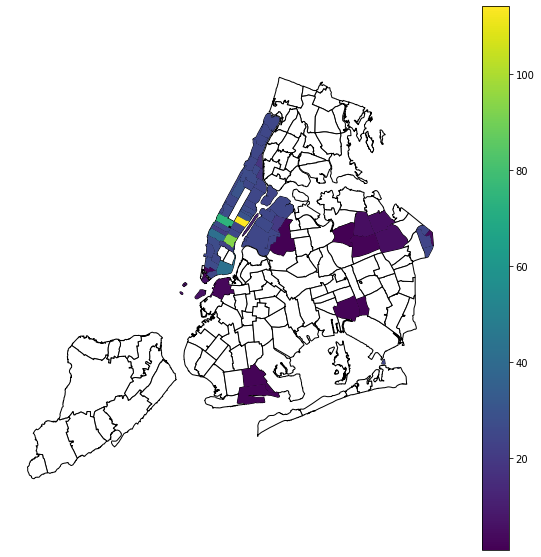

In [657]:
nychousesformaps = zips.merge(nychouses.groupby("zip").count(), right_on="zip", left_on="ZIPCODE")

ax = zips.plot(figsize=(10,10), color="white", ec="k")
ax = nychousesformaps.plot(column="price", ax=ax, legend=True)
ax.axis("off");

In [658]:
nychouses["price"] = pd.to_numeric(nychouses["price"], errors="coerce")

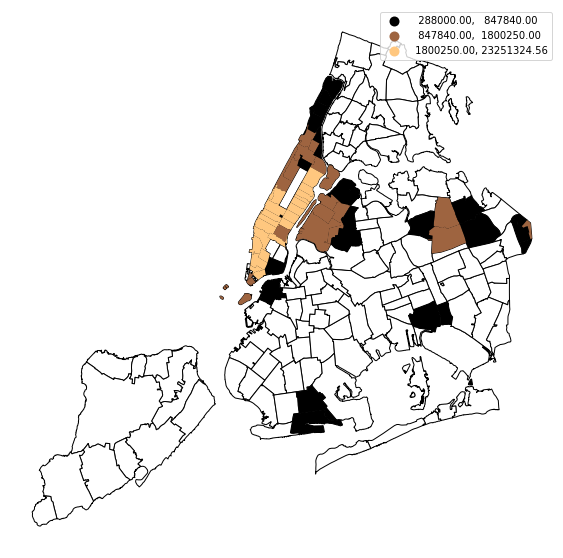

In [659]:
nychousesformaps = zips.merge(
    nychouses[["zip", "price"]].groupby("zip").mean(), 
    right_on="zip", left_on="ZIPCODE")

ax = zips.plot(figsize=(10,10), color="white", ec="k")
ax = nychousesformaps.plot(column="price",  cmap="copper", scheme='quantiles', 
                           k=3, ax=ax, legend=True)
ax.axis("off");

In [660]:
nychouses = nychouses.merge(zips[["ZIPCODE"]], left_on="zip", right_on="ZIPCODE")

### clean up data

I am only going to use three features: zipcode, size of the home, bedrooms, bathrooms, dropping everything else

In [661]:
nychouses.drop(["ZIPCODE", 'city', 'state', 'url', 'address'], axis=1, inplace=True)

In [662]:
nychouses.columns


Index(['zip', 'price', 'sqft', 'bedrooms', 'bathrooms', 'days_on_zillow',
       'sale_type'],
      dtype='object')

In [663]:
#days on zillow would be interesting, but it came up as nan
nychouses.drop(["days_on_zillow"], axis=1, inplace=True)

In [664]:
# removing nans cause sklearn random forest cant deal with them
nychouses.dropna(inplace=True)

In [665]:
for f in [u'price',           u'sqft',
             u'bedrooms',      u'bathrooms']:  
    nychouses[f] = nychouses[f].map(float)

In [666]:
nychouses.head()

,zip,price,sqft,bedrooms,bathrooms,sale_type
0,10001,2599988.0,1536.0,2.0,2.0,Condo For Sale
1,10001,7575000.0,2497.0,2.0,3.0,Condo For Sale
2,10001,8475000.0,2515.0,3.0,4.0,Condo For Sale
3,10001,3550000.0,1755.0,2.0,2.0,Condo For Sale
4,10001,4420000.0,1460.0,2.0,3.0,Condo For Sale


### It is always a good idea to try and solve a simple problem before you embark in finding a solution to a really hard one. In this case, the ultimate goal will be to predict the price of a house based on a small number of characteristics (hard). An easire related problem is to categorize if the house his very expensive or not very expensive: I create a categorical target variable from the price (this will also allow me to demonstrate classification trees):
is price >1M -> 1

else -> 0

In [667]:
yc = np.array([1 if c > 1e6 else 0 for c in nychouses.price])
yc

array([1, 1, 1, ..., 1, 0, 0])

### Option 1 to deal with categorical data

In [668]:
nychouses.sale_type.unique()

array(['Condo For Sale', 'Townhouse For Sale', 'For Sale by Owner',
       'Co-op For Sale', 'Apartment For Sale', 'House For Sale',
       'New Construction', 'Foreclosure', 'Foreclosed', 'Auction'],
      dtype=object)

technically each feature should be a binary - one-hot encoding this feature would generate 10 binary features (is it a Condo For Sale y/2, is it a Foreclosure Y/N) but of there are few choices it is also ok to encode them as numerical features.

In [669]:
nychouses["sale_type_num"] = pd.Categorical(nychouses.sale_type).codes

In [670]:
nychouses.head()

,zip,price,sqft,bedrooms,bathrooms,sale_type,sale_type_num
0,10001,2599988.0,1536.0,2.0,2.0,Condo For Sale,3
1,10001,7575000.0,2497.0,2.0,3.0,Condo For Sale,3
2,10001,8475000.0,2515.0,3.0,4.0,Condo For Sale,3
3,10001,3550000.0,1755.0,2.0,2.0,Condo For Sale,3
4,10001,4420000.0,1460.0,2.0,3.0,Condo For Sale,3


#### whitening

while if I use tree based models whitening the data is not strictly necessary it is good to work with ~unity variables. My target variable is in ~100K or ~1M . I will scale it to be ~1

In [671]:
Xnum = preprocessing.scale(nychouses.drop(["price","sale_type"], axis=1))
yy = preprocessing.scale(nychouses.price)

### Option 2 to deal w categorical data: one-hot encoding
1hot encoding all categorical data: sale_type and zipcode as well

In [672]:
nyc1hot = pd.merge(nychouses, pd.get_dummies(nychouses[u'zip']), 
         left_index=True, right_index=True).merge(pd.get_dummies(nychouses["sale_type"]), 
                                                  left_index=True, 
                                                  right_index=True).drop(["zip", "sale_type", 
                                                                          "sale_type_num"], 
                                                                    axis=1)
nyc1hot.head()

,price,sqft,bedrooms,bathrooms,10001,10002,10004,10006,10007,10010,10011,10012,10013,10014,10016,10017,10018,10019,10021,10022,10023,10024,10025,10026,10027,10028,10029,10030,10031,10032,10033,10034,10035,10036,10037,10038,10039,10040,10044,10065,10069,10075,10128,11001,11004,11005,11040,11096,11101,11102,11103,11104,11105,11106,11109,11201,11229,11235,11355,11361,11364,11365,11436,Apartment For Sale,Auction,Co-op For Sale,Condo For Sale,For Sale by Owner,Foreclosed,Foreclosure,House For Sale,New Construction,Townhouse For Sale
0,2599988.0,1536.0,2.0,2.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,7575000.0,2497.0,2.0,3.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,8475000.0,2515.0,3.0,4.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,3550000.0,1755.0,2.0,2.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,4420000.0,1460.0,2.0,3.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [673]:
nyc1hot.columns

Index(['price', 'sqft', 'bedrooms', 'bathrooms', '10001', '10002', '10004',
       '10006', '10007', '10010', '10011', '10012', '10013', '10014', '10016',
       '10017', '10018', '10019', '10021', '10022', '10023', '10024', '10025',
       '10026', '10027', '10028', '10029', '10030', '10031', '10032', '10033',
       '10034', '10035', '10036', '10037', '10038', '10039', '10040', '10044',
       '10065', '10069', '10075', '10128', '11001', '11004', '11005', '11040',
       '11096', '11101', '11102', '11103', '11104', '11105', '11106', '11109',
       '11201', '11229', '11235', '11355', '11361', '11364', '11365', '11436',
       'Apartment For Sale', 'Auction', 'Co-op For Sale', 'Condo For Sale',
       'For Sale by Owner', 'Foreclosed', 'Foreclosure', 'House For Sale',
       'New Construction', 'Townhouse For Sale'],
      dtype='object')

#### whitening

In [674]:
y = preprocessing.scale(nyc1hot.price)
y

array([-0.1529786 ,  0.2247512 ,  0.29308406, ...,  1.61988051,
       -0.28668233, -0.31629324])

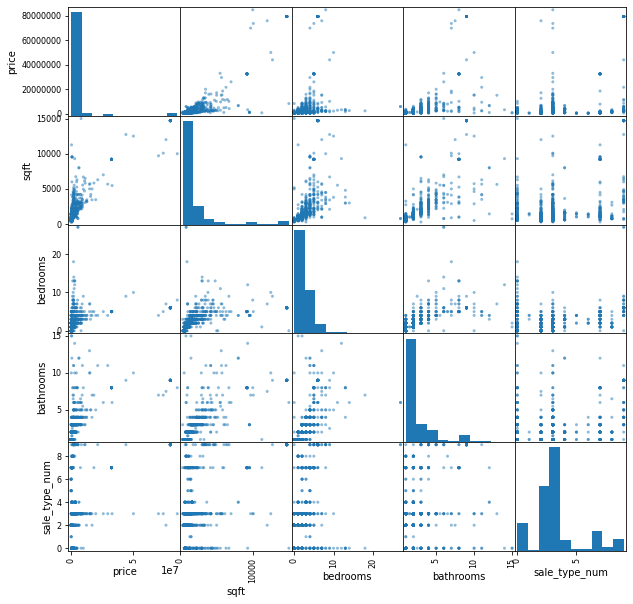

In [675]:
#takse too long
pd.plotting.scatter_matrix(nychouses, figsize=(10,10));

# The Plan
I will run a bunch of different models under four frameworks arising from the combination of two choices:
- tasks: a regression and a classification 
- categorical encoding: zipcode is encoded as numerical and one-hot-encoded

#Start with a Single Tree Classifier

categorical 1-hot encoded 

In [676]:
print("Shape of the data space", X1hot.shape)

Shape of the data space (1100, 72)


In [677]:
tree.DecisionTreeClassifier?

In [678]:
onetree_1hotencoded =  tree.DecisionTreeClassifier(random_state=112).fit(X1hot, yc)
print ("in-sample score of tree classifier %.6f"%onetree_1hotencoded.score(X1hot, yc))

in-sample score of tree classifier 0.998182


categorical encoded as numerical

In [679]:
print("Shape of the data space", Xnum.shape)

Shape of the data space (1100, 5)


In [680]:
onetree_numencoded =  tree.DecisionTreeClassifier(random_state=112).fit(Xnum, yc)
print ("in-sample score of 1-hot encoded tree classifier %.6f"%onetree_numencoded.score(Xnum, yc))

in-sample score of 1-hot encoded tree classifier 0.998182


 plot trees

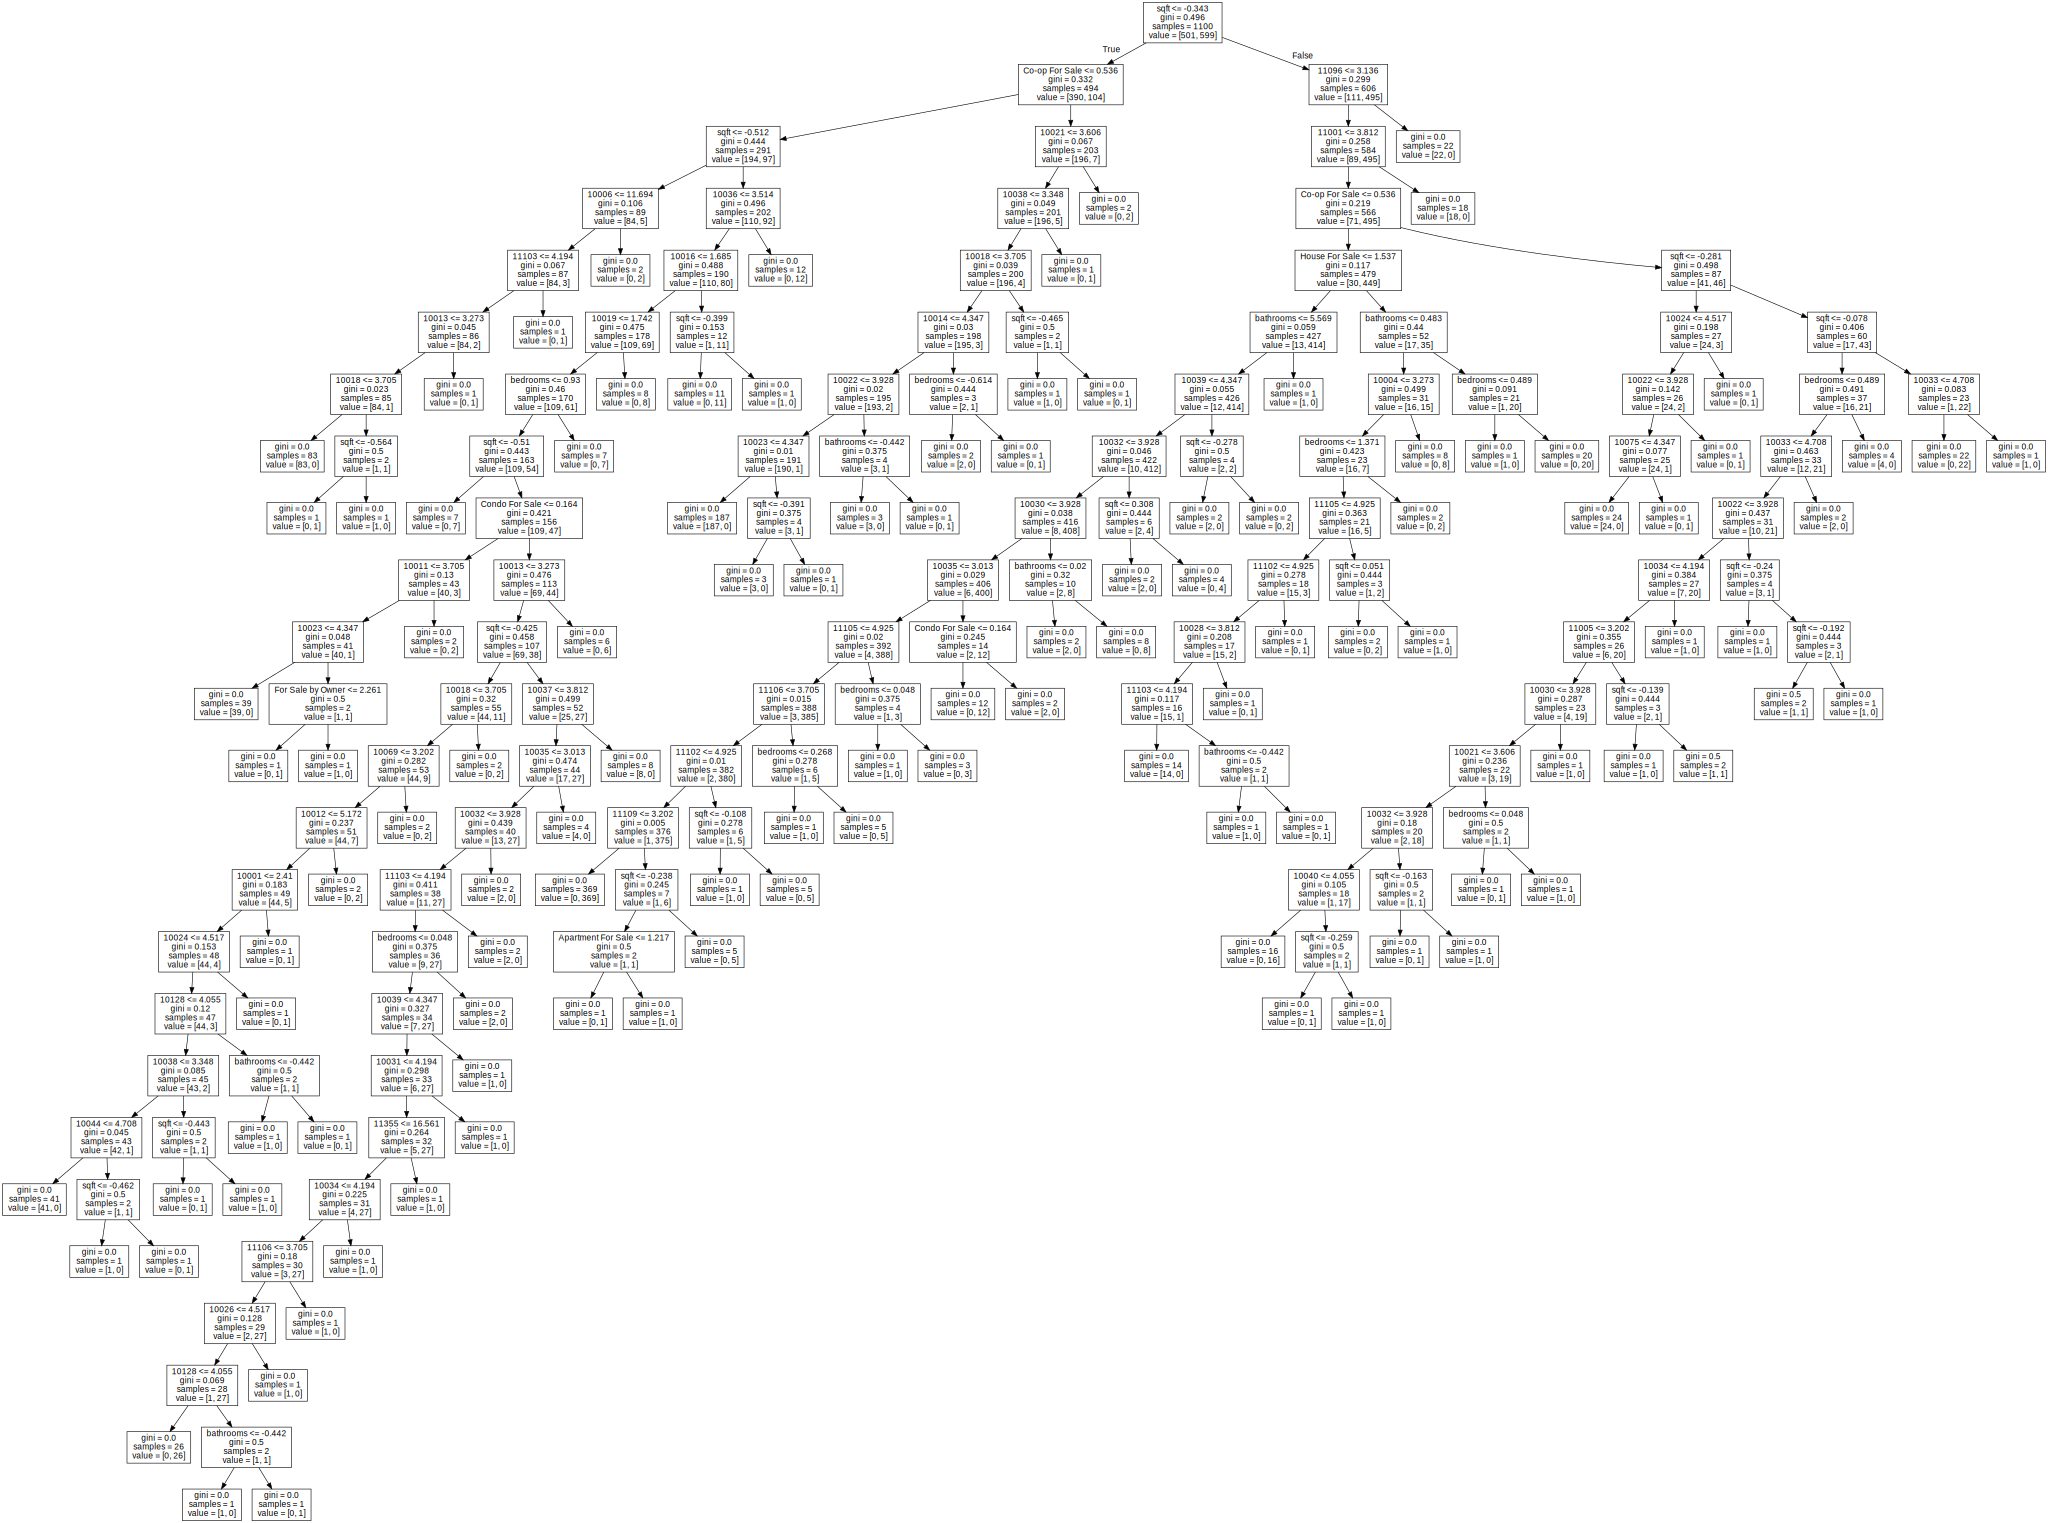

In [681]:
dot_data = tree.export_graphviz(onetree_1hotencoded, 
                                feature_names=nyc1hot.drop("price", axis=1).columns, 
                                out_file=None) 
graph = graphviz.Source(dot_data)
graph

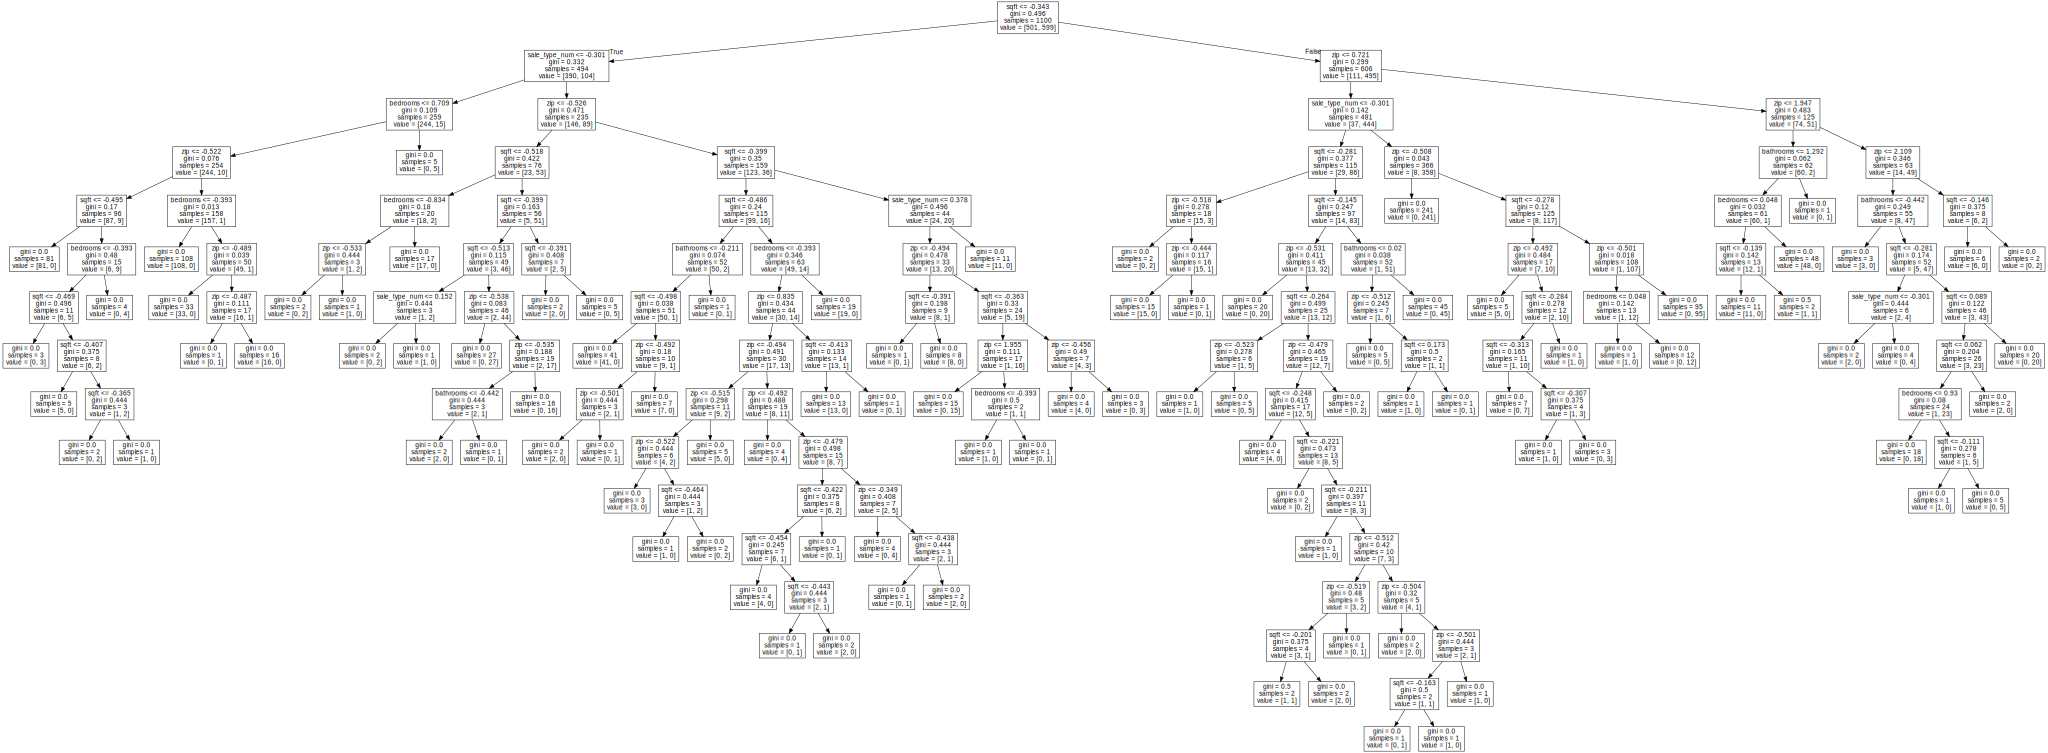

In [682]:
dot_data = tree.export_graphviz(onetree_numencoded, 
                                feature_names=nychouses.drop(["price","sale_type"], axis=1).columns, 
                                out_file=None) 
graph = graphviz.Source(dot_data) 
graph

# comparison with regression models 

In [683]:
# creating a variable for storage of scores
scores = {}
for task in "classification", "regression":
  scores[task] = {}
  for encoding in "numerical", "onehot":
    scores[task][encoding] = {}
    for sample in "in-sample", "out-sample": #let me tell you about this later 
      scores[task][encoding][sample] = {}

In [684]:
# creating a function that will store and print the scores
def printscore(model, modelname, task, encoding):
  if encoding == "onehot":
    X = X1hot_train
    Xtest = X1hot_test
  else:
    X = Xnum_train
    Xtest = Xnum_test
  if task == "regression":
    target = y_train
    targettest = y_test
  else:
    target = yc_train
    targettest = yc_test
  model = model.fit(X, target)
  scores[task][encoding]["in-sample"][modelname] = model.score(X, target)
  print("%s score of %s for %s with %s encoding "%(sample, modelname, task, encoding) + 
        "%.6f"%scores[task][encoding]["in-sample"][modelname])
  scores[task][encoding]["out-sample"][modelname] = model.score(Xtest, targettest)
  print("%s score of %s for %s with %s encoding "%(sample, modelname, task, encoding) + 
        "%.6f"%scores[task][encoding]["out-sample"][modelname])


### split sample into training and testting set (60-30 split)

In [685]:
# regression sample
Xnum_train, Xnum_test, y_train, y_test = train_test_split(Xnum, y, test_size=0.3, random_state=123)

# regression sample one-hot encoded
X1hot_train, X1hot_test, y1hot_train, y1hot_test = train_test_split(X1hot, y, test_size=0.3, random_state=123)

# classsification sample one-hot encoded
X1hot_train, X1hot_test, yc1hot_train, yc1hot_test = train_test_split(X1hot, yc, test_size=0.3, random_state=123)


## Classification

### Ridge classification: regression with penalization for high coefficients (Categorical version)

In [686]:
ridgec = linear_model.RidgeClassifierCV()
printscore(ridgec, "Ridge", "classification", "numerical")

out-sample score of Ridge for classification with numerical encoding 0.820779
out-sample score of Ridge for classification with numerical encoding 0.818182


In [687]:
ridgec = linear_model.RidgeClassifierCV()
printscore(ridgec, "Ridge", "classification", "onehot")

out-sample score of Ridge for classification with onehot encoding 0.924675
out-sample score of Ridge for classification with onehot encoding 0.890909


### Logistic regression (NB: in spite of its name it is a classifier)

In [688]:
logisticc = linear_model.LogisticRegressionCV(max_iter=1000)
printscore(logisticc, "Logistic", "classification", "numerical")

out-sample score of Logistic for classification with numerical encoding 0.831169
out-sample score of Logistic for classification with numerical encoding 0.833333


In [689]:
printscore(logisticc, "Logistic", "classification", "onehot")

out-sample score of Logistic for classification with onehot encoding 0.962338
out-sample score of Logistic for classification with onehot encoding 0.903030


## Tree Classification models

In [690]:
onetree =  tree.DecisionTreeClassifier(random_state=112)
printscore(onetree, "Tree", "classification", "numerical")

out-sample score of Tree for classification with numerical encoding 1.000000
out-sample score of Tree for classification with numerical encoding 0.912121


In [691]:
printscore(onetree, "Tree", "classification", "onehot")

out-sample score of Tree for classification with onehot encoding 1.000000
out-sample score of Tree for classification with onehot encoding 0.881818


### Random Forest

In [692]:
rfc = ensemble.RandomForestClassifier()
printscore(rfc, "RF", "classification", "numerical")

out-sample score of RF for classification with numerical encoding 1.000000
out-sample score of RF for classification with numerical encoding 0.921212


In [693]:
printscore(rfc, "RF", "classification", "onehot")

out-sample score of RF for classification with onehot encoding 1.000000
out-sample score of RF for classification with onehot encoding 0.912121


### Gradient boosted trees

In [694]:
gbc = ensemble.GradientBoostingClassifier()
printscore(gbc, "GB", "classification", "numerical")

out-sample score of GB for classification with numerical encoding 0.980519
out-sample score of GB for classification with numerical encoding 0.933333


In [695]:
printscore(gbc, "GB", "classification", "onehot")

out-sample score of GB for classification with onehot encoding 0.966234
out-sample score of GB for classification with onehot encoding 0.912121


## Regression

### Linear regression

In [696]:
linearReg = linear_model.LinearRegression()
printscore(linearReg, "LR", "regression", "numerical")


out-sample score of LR for regression with numerical encoding 0.825670
out-sample score of LR for regression with numerical encoding 0.747668


In [697]:
printscore(linearReg, "LR", "regression", "onehot")


out-sample score of LR for regression with onehot encoding 0.891713
out-sample score of LR for regression with onehot encoding 0.786179



### Ridge regression: regression with penalization for high coefficients

In [698]:
ridge = linear_model.RidgeCV()
printscore(ridge, "Ridge", "regression", "numerical")

out-sample score of Ridge for regression with numerical encoding 0.825663
out-sample score of Ridge for regression with numerical encoding 0.749059


In [699]:
printscore(ridge, "Ridge", "regression", "onehot")

out-sample score of Ridge for regression with onehot encoding 0.891985
out-sample score of Ridge for regression with onehot encoding 0.790375


## Tree regression models

# Single Tree

In [700]:
onetree =  tree.DecisionTreeRegressor(random_state=112)
printscore(onetree, "Tree", "regression", "numerical")

out-sample score of Tree for regression with numerical encoding 0.999999
out-sample score of Tree for regression with numerical encoding 0.831848


In [701]:
printscore(onetree, "Tree", "regression", "onehot")

out-sample score of Tree for regression with onehot encoding 0.999999
out-sample score of Tree for regression with onehot encoding 0.820020


### Random Forest

In [702]:
rfr = ensemble.RandomForestRegressor()
printscore(rfr, "RF", "regression", "numerical")

out-sample score of RF for regression with numerical encoding 0.993656
out-sample score of RF for regression with numerical encoding 0.823453


In [703]:
printscore(rfr, "RF", "regression", "onehot")

out-sample score of RF for regression with onehot encoding 0.990848
out-sample score of RF for regression with onehot encoding 0.821994


### Gradient boosted trees

In [704]:
gbr = ensemble.GradientBoostingRegressor()
printscore(gbr, "GB", "regression", "numerical")


out-sample score of GB for regression with numerical encoding 0.996452
out-sample score of GB for regression with numerical encoding 0.857293


In [705]:
printscore(gbr, "GB", "regression", "onehot")

out-sample score of GB for regression with onehot encoding 0.994930
out-sample score of GB for regression with onehot encoding 0.851292


### NOTE: these models are almost all overfitting and need to be pruned or controlled via (e.g.) max depth!

In [706]:
import pprint
pprint.pprint(scores)

{'classification': {'numerical': {'in-sample': {'GB': 0.9805194805194806,
                                                'Logistic': 0.8311688311688312,
                                                'RF': 1.0,
                                                'Ridge': 0.8207792207792208,
                                                'Tree': 1.0},
                                  'out-sample': {'GB': 0.9333333333333333,
                                                 'Logistic': 0.8333333333333334,
                                                 'RF': 0.9212121212121213,
                                                 'Ridge': 0.8181818181818182,
                                                 'Tree': 0.9121212121212121}},
                    'onehot': {'in-sample': {'GB': 0.9662337662337662,
                                             'Logistic': 0.9623376623376624,
                                             'RF': 1.0,
                                             'Ridge': 0.

In [718]:
print("{:<14} {:<11} {:<8} {:<8} {:<8}\t\t".format(
    "","","","regression", "","CART"))
print("{:<14} {:<11} {:<6} {:<9} {:<8} {:<8} {:<8} {:<8}\t\t".format(
    "purpose","encoding","linear","logistic", "ridge","tree","RF","GBT"))

for task in ["regression", "classification"]:
  for encoding in ["numerical", "onehot"]:
    input = [task, encoding]
    for model in ["LR", "Logistic", "Ridge", "Tree", "RF", "GB"]:
      try:
        input = input + [int(scores[task][encoding]["in-sample"][model]*100)] + \
                       [int(scores[task][encoding]["out-sample"][model]*100)]
      
      except:
        #print("cant do", task, encoding, model)
        input = input + [''] + ['']
    print("{:<14} {:<11} {:<2}/{:<4} {:<2}/{:<4} {:<3}/{:<4} {:<3}/{:<4} {:<3}/{:<4} {:<3}/{:<4}\t\t".format(
        *input))


                                    regression         		
purpose        encoding    linear logistic  ridge    tree     RF       GBT     		
regression     numerical   82/74     /     82 /74   99 /83   99 /82   99 /85  		
regression     onehot      89/78     /     89 /79   99 /82   99 /82   99 /85  		
classification numerical     /     83/83   82 /81   100/91   100/92   98 /93  		
classification onehot        /     96/90   92 /89   100/88   100/91   96 /91  		


## ROC curves provide a better metric for comparison: 
plot false positive rate vs false negative rate (completeness vs accuracy)

In [633]:
# evaluate the model using 10-fold cross-validation
print ("one-hot encoding")

scores = cross_val_score(ensemble.RandomForestClassifier(), 
                         X1hot_train, yc_train, scoring='roc_auc', cv=10)
print("Ridge {:.2f}".format(scores.mean()))

scores = cross_val_score(ensemble.RandomForestClassifier(), 
                         X1hot_train, yc_train, scoring='roc_auc', cv=10)
print("RF {:.2f}".format(scores.mean()))

scores = cross_val_score(ensemble.RandomForestClassifier(), 
                         X1hot_train, yc_train, scoring='roc_auc', cv=10)
print("GBT {:.2f}".format(scores.mean()))

one-hot encoding
Ridge 0.98
RF 0.98
GBT 0.98


In [634]:
print ("numerical encoding")

scores = cross_val_score(ensemble.RandomForestClassifier(), 
                         Xnum_train, yc_train, scoring='roc_auc', cv=10)
print("Ridge {:.2f}".format(scores.mean()))

scores = cross_val_score(ensemble.RandomForestClassifier(), 
                         Xnum_train, yc_train, scoring='roc_auc', cv=10)
      
print("RF {:.2f}".format(scores.mean()))

scores = cross_val_score(ensemble.RandomForestClassifier(), 
                         Xnum_train, yc_train, scoring='roc_auc', cv=10)
print("GBT {:.2f}".format(scores.mean()))

numerical encoding
Ridge 0.98
RF 0.98
GBT 0.98


In [635]:
fpr_grd_logit, tpr_grd_logit, _ = metrics.roc_curve(yc_test, 
                                                    y_pred_grd_logit)


In [636]:
y_pred_grd_logit = logisticc.predict(X1hot_test)
fpr_grd_logit, tpr_grd_logit, _ = metrics.roc_curve(yc_test, 
                                                    y_pred_grd_logit)
y_pred_grd_ridge = ridgec.predict(X1hot_test)
fpr_grd_ridge, tpr_grd_ridge, _ = metrics.roc_curve(yc_test, y_pred_grd_ridge)

rfnum = ensemble.RandomForestClassifier().fit(Xnum_train, yc_train)
y_pred_grd_rfnum = rfnum.predict_proba(Xnum_test)[:, 1]
fpr_grd_rf, tpr_grd_rf, _ = metrics.roc_curve(yc_test, y_pred_grd_rfnum)

rf1hot = ensemble.RandomForestClassifier().fit(X1hot_train, yc_train)
y_pred_grd_rfcat = rf1hot.predict_proba(X1hot_test)[:, 1]
fpr_grd_rfcat, tpr_grd_rfcat, _ = metrics.roc_curve(yc_test, y_pred_grd_rfcat)

gbnum = ensemble.GradientBoostingClassifier().fit(Xnum_train, yc_train)
y_pred_grd_gbnum = gbnum.predict_proba(Xnum_test)[:, 1]
fpr_grd_gb, tpr_grd_gb, _ = metrics.roc_curve(yc_test, y_pred_grd_gbnum)

gb1hot = ensemble.GradientBoostingClassifier().fit(X1hot_train, yc_train)
y_pred_grd_gbcat = gb1hot.predict_proba(X1hot_test)[:, 1]
fpr_grd_gbcat, tpr_grd_gbcatt, _ = metrics.roc_curve(yc_test, y_pred_grd_gbcat)

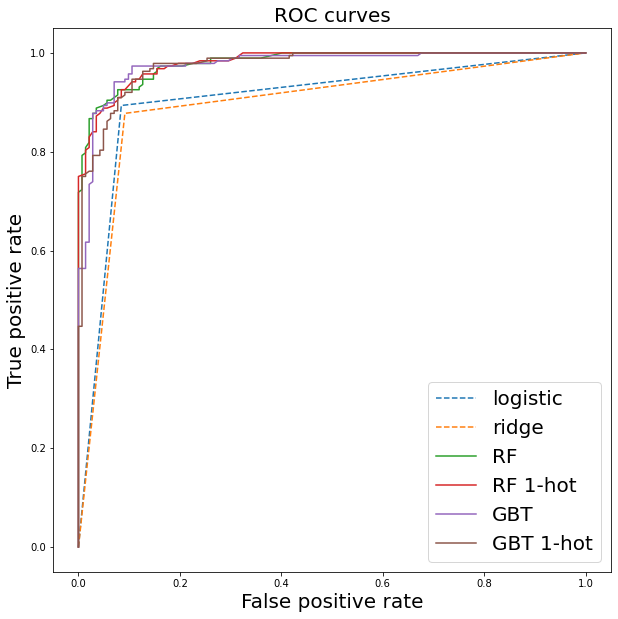

In [637]:
pl.figure(figsize=(10,10))
pl.plot(fpr_grd_logit, tpr_grd_logit, '--', label='logistic')
pl.plot(fpr_grd_ridge, tpr_grd_ridge, '--', label='ridge')
pl.plot(fpr_grd_rf, tpr_grd_rf, label='RF')
pl.plot(fpr_grd_rfcat, tpr_grd_rfcat, label='RF 1-hot')
pl.plot(fpr_grd_gb, tpr_grd_gb, label='GBT')
pl.plot(fpr_grd_gbcat, tpr_grd_gbcatt, label='GBT 1-hot')
pl.legend(fontsize=20)
pl.xlabel('False positive rate', fontsize=20)
pl.ylabel('True positive rate', fontsize=20)
pl.title('ROC curves', fontsize=20);

# the best part is feature importance

In [638]:
#the feature importance is a measure of how soon and how often a feature was used and is encded as a 0-1 number per feature
rfnum.feature_importances_

array([0.29256885, 0.32922941, 0.07669513, 0.17976363, 0.12174299])

In [639]:
importancesrf = rfnum.feature_importances_
importancesrf
std = np.std([onetree.feature_importances_ for onetree in rfnum.estimators_],
             axis=0)
indicesrf = np.argsort(importancesrf)[::-1]




# Print the feature ranking
print("Feature ranking:")

for f in range(Xnum_train.shape[1]):
    print("%d. feature %d %s (%f)" % (f + 1, indicesrf[f], 
                                   nychouses.drop(["price","sale_type"], axis=1).columns[
                indicesrf[f]],
                                   importancesrf[indicesrf[f]]))


Feature ranking:
1. feature 1 sqft (0.329229)
2. feature 0 zip (0.292569)
3. feature 3 bathrooms (0.179764)
4. feature 4 sale_type_num (0.121743)
5. feature 2 bedrooms (0.076695)


In [640]:
importancesrfcat = rf1hot.feature_importances_
indicesrfcat = np.argsort(importancesrfcat)[::-1]

# Print the feature ranking
print("Feature ranking:")

for f in range(X1hot_train.shape[1]):
    print("%d. feature %d %s (%f)" % (f + 1, indicesrfcat[f], 
                                   nyc1hot.drop("price", axis=1).columns[
                indicesrfcat[f]],
                                   importancesrfcat[indicesrfcat[f]]))


Feature ranking:
1. feature 0 sqft (0.243974)
2. feature 2 bathrooms (0.165045)
3. feature 1 bedrooms (0.080283)
4. feature 64 Co-op For Sale (0.071863)
5. feature 65 Condo For Sale (0.035369)
6. feature 46 11096 (0.030692)
7. feature 16 10019 (0.022587)
8. feature 42 11001 (0.021173)
9. feature 69 House For Sale (0.019141)
10. feature 13 10016 (0.015550)
11. feature 44 11005 (0.012133)
12. feature 17 10021 (0.011195)
13. feature 11 10013 (0.010851)
14. feature 35 10039 (0.010441)
15. feature 62 Apartment For Sale (0.010258)
16. feature 32 10036 (0.009737)
17. feature 31 10035 (0.009378)
18. feature 71 Townhouse For Sale (0.009354)
19. feature 39 10069 (0.009196)
20. feature 5 10004 (0.009183)
21. feature 28 10032 (0.008822)
22. feature 3 10001 (0.008701)
23. feature 33 10037 (0.008473)
24. feature 70 New Construction (0.007446)
25. feature 15 10018 (0.007162)
26. feature 43 11004 (0.006947)
27. feature 52 11106 (0.006476)
28. feature 49 11103 (0.006279)
29. feature 22 10026 (0.006200)

In [641]:
gbnum.feature_importances_

array([0.38263019, 0.32017378, 0.01192754, 0.21951905, 0.06574943])

In [642]:
importancesgbc = gbnum.feature_importances_
indicesgbc = np.argsort(importancesgbc)[::-1]

# Print the feature ranking
print("Feature ranking:")

for f in range(Xnum.shape[1]):
    print("%d. feature %d %s (%f)" % (f + 1, indicesgbc[f], 
                                   nychouses.drop(["price","sale_type"], axis=1).columns[
                indicesgbc[f]],
                                   importancesgbc[indicesgbc[f]]))


Feature ranking:
1. feature 0 zip (0.382630)
2. feature 1 sqft (0.320174)
3. feature 3 bathrooms (0.219519)
4. feature 4 sale_type_num (0.065749)
5. feature 2 bedrooms (0.011928)


In [643]:
importancesgbcat = gb1hot.feature_importances_
indicesgbcat = np.argsort(importancesgbcat)[::-1]

# Print the feature ranking
print("Feature ranking:")

for f in range(X1hot.shape[1]):
    print("%d. feature %d %s (%f)" % (f + 1, indicesgbcat[f], 
                                   nyc1hot.drop(["price"], axis=1).columns[
                indicesgbcat[f]],
                                   importancesgbcat[indicesgbcat[f]]))


Feature ranking:
1. feature 0 sqft (0.342225)
2. feature 2 bathrooms (0.194393)
3. feature 64 Co-op For Sale (0.090810)
4. feature 46 11096 (0.065785)
5. feature 42 11001 (0.043384)
6. feature 69 House For Sale (0.038086)
7. feature 65 Condo For Sale (0.033484)
8. feature 17 10021 (0.014243)
9. feature 44 11005 (0.013871)
10. feature 16 10019 (0.013445)
11. feature 43 11004 (0.012916)
12. feature 11 10013 (0.011440)
13. feature 13 10016 (0.010998)
14. feature 45 11040 (0.009486)
15. feature 1 bedrooms (0.008739)
16. feature 32 10036 (0.007997)
17. feature 39 10069 (0.006821)
18. feature 35 10039 (0.006790)
19. feature 70 New Construction (0.006570)
20. feature 29 10033 (0.006481)
21. feature 33 10037 (0.005381)
22. feature 5 10004 (0.005321)
23. feature 31 10035 (0.004914)
24. feature 15 10018 (0.004465)
25. feature 6 10006 (0.003927)
26. feature 28 10032 (0.003490)
27. feature 49 11103 (0.003094)
28. feature 9 10011 (0.003030)
29. feature 62 Apartment For Sale (0.002917)
30. feature 5

# Feature importance - numerical encoding

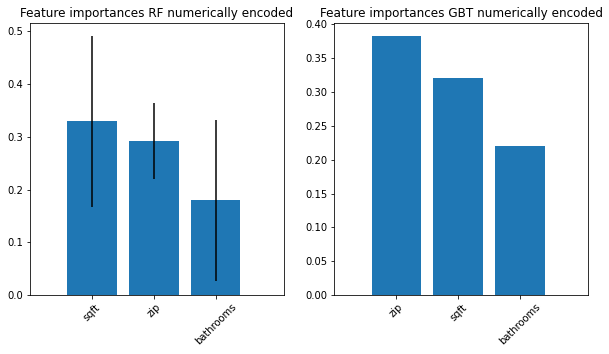

In [644]:
import pylab as pl
fig = pl.figure(figsize=(10,5))

ax = fig.add_subplot(121)
importances = rfnum.feature_importances_
importances
std = np.std([onetree.feature_importances_ for onetree in rfnum.estimators_],
             axis=0)
indices = np.argsort(importances)[::-1]



# Plot the feature importances of the forest
Nf = 3
pl.title("Feature importances RF numerically encoded")
pl.bar(range(Nf), importances[indices[:Nf]],
       yerr=std[indices[:Nf]], align="center")
pl.xticks(range(Nf), nychouses.drop(["price","sale_type"], axis=1).columns[indices[:Nf]])
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)
pl.xlim([-1, Nf + 0.1])

importances = gbnum.feature_importances_
importances
indices = np.argsort(importances)[::-1]


ax = fig.add_subplot(122)

# Plot the feature importances of the forest

pl.title("Feature importances GBT numerically encoded")
pl.bar(range(Nf), importances[indices[:Nf]], align="center")
pl.xticks(range(Nf), nychouses.drop(["price","sale_type"], axis=1).columns[indices[:Nf]])
pl.xlim([-1, Nf + 0.1])
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)
pl.show()


# Feature importance: one-hot encoding

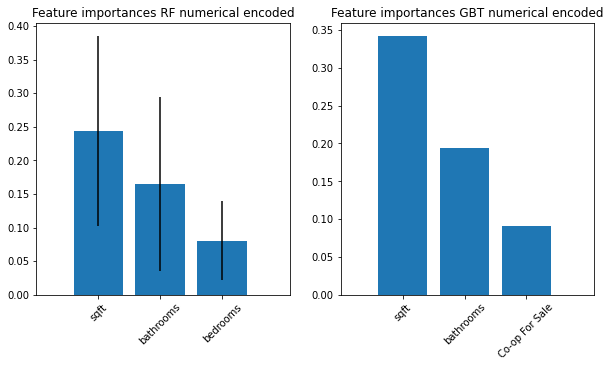

In [645]:
fig = pl.figure(figsize=(10,5))

ax = fig.add_subplot(121)
importances = rf1hot.feature_importances_
importances
std = np.std([onetree.feature_importances_ for onetree in rf1hot.estimators_],
             axis=0)
indices = np.argsort(importances)[::-1]



# Plot the feature importances of the forest

pl.title("Feature importances RF numerical encoded")
pl.bar(range(Nf), importances[indices[:Nf]],
       yerr=std[indices[:Nf]], align="center")
pl.xticks(range(Nf), nyc1hot.drop(["price"], axis=1).columns[indices[:Nf]])
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)
pl.xlim([-1, Nf + 0.1])

importances = gb1hot.feature_importances_
importances
indices = np.argsort(importances)[::-1]


ax = fig.add_subplot(122)

# Plot the feature importances of the forest
Nf = 3
pl.title("Feature importances GBT numerical encoded")
pl.bar(range(Nf), importances[indices[:Nf]], align="center")
pl.xticks(range(Nf), nyc1hot.drop(["price"], axis=1).columns[indices[:Nf]])
pl.xlim([-1, Nf + 0.1])
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)

pl.show()

# The moral of the story is: beware of hot encoding and feature importance!